<a href="https://colab.research.google.com/github/shahed-maumer/Machine-Learning-/blob/main/Practical_Exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
##الاسم: شهد محمد مرزوق معمر
##الرقم الجامعي:2320224113

In [2]:
#Import Librarie:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
#Upload Dataset:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [4]:
#Load Dataset:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
#Data Cleaning:
df = df.dropna()
df = df.drop_duplicates()

In [6]:
#Outliers Removal:
Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['charges'] >= lower) & (df['charges'] <= upper)]

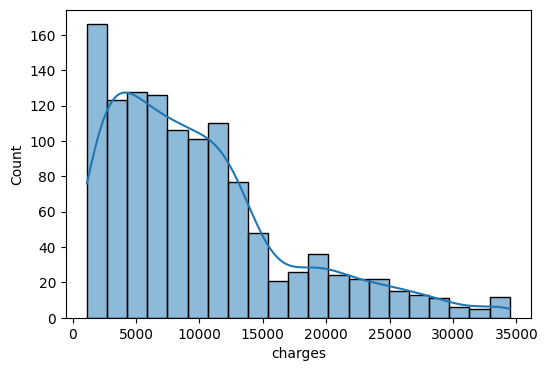

In [7]:
#EDA - Histogram:
plt.figure(figsize=(6,4))
sns.histplot(df['charges'], kde=True)
plt.show()

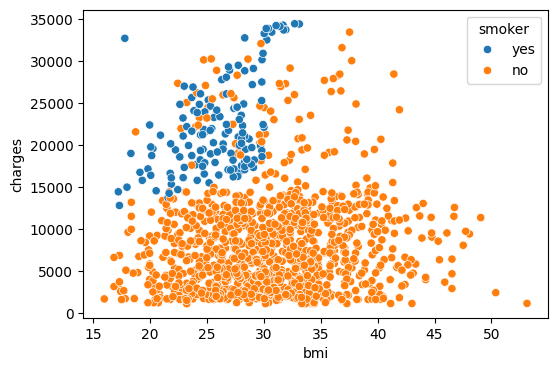

In [8]:
#EDA - Scatter Plot:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker')
plt.show()

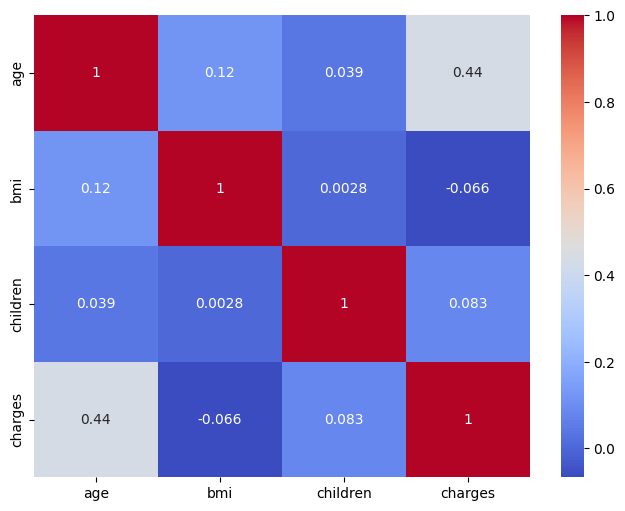

In [9]:
#Correlation Heatmap:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [10]:
#Split Features:
X = df.drop('charges', axis=1)
y = df['charges']

categorical_cols = ['sex', 'smoker', 'region']
numerical_cols = ['age', 'bmi', 'children']

In [11]:
#Preprocessing:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)

In [12]:
#Train-Test Split:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
#Linear Regression:
lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("Linear Regression R2:", r2_score(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))

Linear Regression R2: 0.5746461537143135
RMSE: 4783.391029048692


In [14]:
#Ridge Regression:
ridge_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

print("Ridge R2:", r2_score(y_test, ridge_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))

Ridge R2: 0.5759086675298153
RMSE: 4776.286843662033


In [15]:
#Cross Validation (Ridge):
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

ridge_cv_scores = cross_val_score(
    ridge_model, X_train, y_train, cv=kfold, scoring='r2'
)

print("CV Scores:", ridge_cv_scores)
print("Mean CV:", ridge_cv_scores.mean())
print("STD:", ridge_cv_scores.std())

CV Scores: [0.59424368 0.55220709 0.54454407 0.67396333 0.63780332]
Mean CV: 0.6005522946635538
STD: 0.04957983068758048


In [16]:
#Lasso Regression:
lasso_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=0.01))
])

lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)

print("Lasso R2:", r2_score(y_test, lasso_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lasso_pred)))

Lasso R2: 0.5746474972600911
RMSE: 4783.383474503282


In [17]:
print("="*40)
print("SUMMARY")
print("="*40)

print("Dataset shape:", df.shape)
print("Train samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

print("Linear R2:", r2_score(y_test, lr_pred))
print("Ridge R2:", r2_score(y_test, ridge_pred))
print("CV Mean R2:", ridge_cv_scores.mean())

SUMMARY
Dataset shape: (1198, 7)
Train samples: 958
Test samples: 240
Linear R2: 0.5746461537143135
Ridge R2: 0.5759086675298153
CV Mean R2: 0.6005522946635538
